# Machine Learning - Métricas de Modelagem 01

1. Diferença de Train, valid e test:

- 📚 Treino (70%) → o aluno estuda
- 📝 Validação (15%) → simulados para ajustar o método de estudo
- 🎓 Teste (15%) → prova final

2. Matriz de Confusão

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("emp_automovel.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54025 entries, 0 to 54024
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   receita_cliente      54025 non-null  float64
 1   anuidade_emprestimo  54025 non-null  float64
 2   anos_casa_propria    54025 non-null  float64
 3   telefone_trab        54025 non-null  int64  
 4   avaliacao_cidade     54025 non-null  float64
 5   score_1              54025 non-null  float64
 6   score_2              54025 non-null  float64
 7   score_3              54025 non-null  float64
 8   score_social         54025 non-null  float64
 9   troca_telefone       54025 non-null  float64
 10  inadimplente         54025 non-null  int64  
dtypes: float64(9), int64(2)
memory usage: 4.5 MB


In [4]:
X = df.drop('inadimplente', axis=1)
y = df['inadimplente']

Distribuição do target:

<Axes: xlabel='inadimplente'>

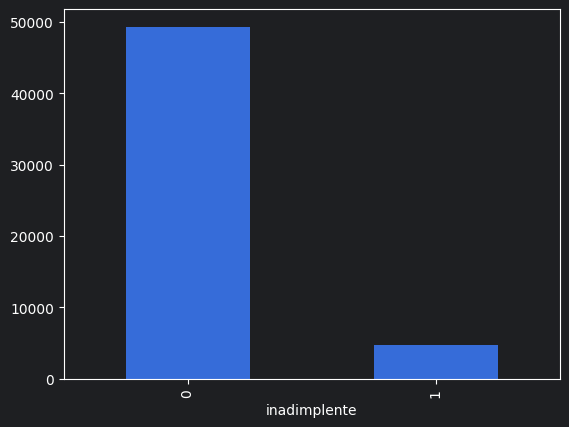

In [5]:
y.value_counts().plot(kind='bar')

## Modelo de Base (Dummy) & Arvore de Decisão
Vamos utilizar um modelo simples para classificar os dados. Este modelo serve como critério de comparação para identificar se os outros modelos tem um melhor desempenho do que a classificação mais simples possivel, classificando com base no valor de maior frequência do target

In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split

In [10]:
modelo = DecisionTreeClassifier(random_state=42, ) #max_depht
dummy = DummyClassifier(random_state=42)

In [12]:
dummy.fit(X, y)
modelo.fit(X, y)



print("Avore de decisão: ", modelo.score(X,y))
print("Dummy: ", dummy.score(X,y))

Avore de decisão:  1.0
Dummy:  0.9127070800555298


### Vamos treinar o modelo com o dataset completo para receber novos dados

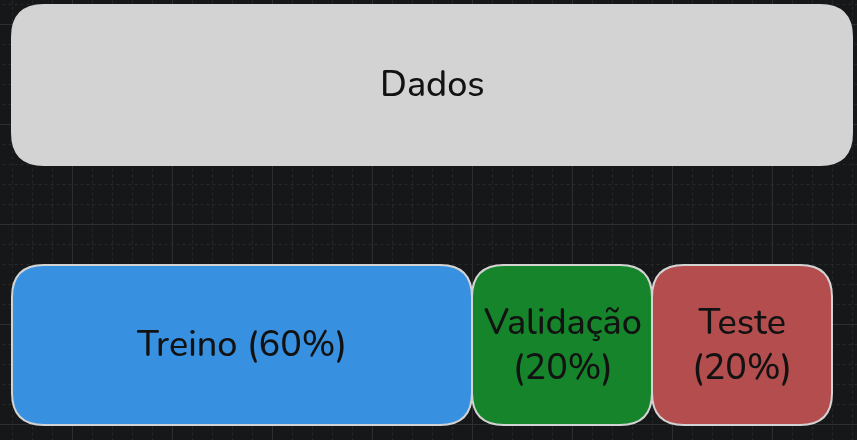

# Dividindo o Dataset em Treino, Validação e Teste

Para que um modelo de Machine Learning seja avaliado corretamente, é importante dividir o dataset em três conjuntos:

- **Treino:** utilizado para o modelo aprender os padrões dos dados.
- **Validação:** utilizado para ajustar hiperparâmetros e comparar modelos.
- **Teste:** utilizado apenas no final para medir o desempenho real do modelo.

## Código

```python
from sklearn.model_selection import train_test_split

# 1ª divisão: separa o conjunto de teste
X, X_teste, y, y_teste = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 2ª divisão: separa treino e validação
X_treino, X_validacao, y_treino, y_validacao = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
```

---

# Primeira divisão

```python
X, X_teste, y, y_teste = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
```

Nesta etapa, o dataset é dividido em dois conjuntos:

- **80%** dos dados permanecem em `X` e `y`;
- **20%** são separados para `X_teste` e `y_teste`.

Representação:

```
Dataset (100%)

├── X, y (80%)
└── X_teste, y_teste (20%)
```

O conjunto de teste será utilizado apenas ao final do desenvolvimento do modelo.

---

# Segunda divisão

```python
X_treino, X_validacao, y_treino, y_validacao = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
```

Agora o código divide apenas os **80% restantes**.

Desses 80%:

- **80%** tornam-se o conjunto de treino;
- **20%** tornam-se o conjunto de validação.

Representação:

```
80% restantes

├── Treino (80%)
└── Validação (20%)
```

Como essa divisão acontece apenas sobre os 80% restantes, a proporção final do dataset será:

| Conjunto | Percentual |
|----------|-----------:|
| Treino | 64% |
| Validação | 16% |
| Teste | 20% |

---

# O parâmetro `test_size`

O parâmetro `test_size` define a porcentagem dos dados que será destinada ao segundo conjunto gerado pela função.

```python
test_size=0.2
```

Significa que **20% dos dados serão separados**, enquanto os outros **80% permanecerão no primeiro conjunto**.

---

# O parâmetro `random_state`

Antes de realizar a divisão, o Scikit-Learn embaralha os dados.

```python
random_state=42
```

Esse parâmetro fixa a semente do gerador de números aleatórios, garantindo que a divisão seja sempre a mesma.

Sem ele, cada execução produziria uma divisão diferente.

---

# O que representa cada variável?

| Variável | Descrição |
|----------|-----------|
| `X` | Variáveis de entrada (features). |
| `y` | Variável alvo (target). |
| `X_treino` | Features utilizadas para treinar o modelo. |
| `y_treino` | Respostas correspondentes ao conjunto de treino. |
| `X_validacao` | Features utilizadas para validar o modelo. |
| `y_validacao` | Respostas correspondentes ao conjunto de validação. |
| `X_teste` | Features utilizadas apenas na avaliação final. |
| `y_teste` | Respostas correspondentes ao conjunto de teste. |

---

# Fluxo da divisão

```
                Dataset (100%)
                      │
                      ▼
          Primeira divisão (20%)
                      │
          ┌───────────┴───────────┐
          │                       │
      80% (X, y)             20% Teste
          │
          ▼
    Segunda divisão (20%)
          │
     ┌────┴────┐
     │         │
Treino (64%)  Validação (16%)
```

---

# Observação

Embora o código funcione corretamente, uma forma mais legível é utilizar nomes intermediários, como `X_train_val` e `y_train_val`, deixando explícito que esses dados ainda serão divididos entre treino e validação.

Além disso, quando o problema possui classes desbalanceadas, recomenda-se utilizar:

```python
stratify=y
```

na primeira divisão e

```python
stratify=y_train_val
```

na segunda divisão, garantindo que a proporção das classes seja preservada em todos os conjuntos.

In [13]:
X, X_teste, y, y_teste, = train_test_split(X, y, test_size=0.2, random_state=42)
X_treino, X_validacao , y_treino, y_validacao = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
modelo = DecisionTreeClassifier(random_state=42) # criando outro modelo resetar o fit
modelo.fit(X_treino, y_treino)

print("Acuracia em dados de treino: ", modelo.score(X_treino, y_treino))
print("Acuracia em dados de validacao: ", modelo.score(X_validacao, y_validacao))

Acuracia em dados de treino:  1.0
Acuracia em dados de validacao:  0.8512262841277186


Observe a queda de 15%.  Isso nos indica que o modelo deu overfiting. Vamos ajustar a profundidade das arvóres

In [44]:
modelo = DecisionTreeClassifier(random_state=42, max_depth=10) # criando outro modelo resetar o fit
modelo.fit(X_treino, y_treino)

print("Acuracia em dados de treino: ", modelo.score(X_treino, y_treino))
print("Acuracia em dados de validacao: ", modelo.score(X_validacao, y_validacao))

Acuracia em dados de treino:  0.919452799629801
Acuracia em dados de validacao:  0.9111522443313281


**obeservação: o modelo está com alta acurácia mesmo com max_depth=1 pois nós temos um desbalanceamento de classes**

# Avaliando Modelo

In [33]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [45]:
y_previsto = modelo.predict(X_validacao)
matriz_confusao = confusion_matrix(y_validacao, y_previsto)
print(matriz_confusao)

[[7857   40]
 [ 728   19]]


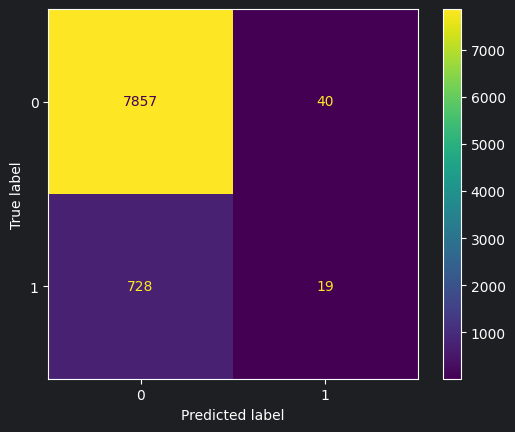

In [46]:
view = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao)
view.plot() # ; (PONTO E VIRGULA) para não exibir a mensagem de texto que aparece logo após a plotagem

- True Label: Valores Reais (y_validacao)
- Predicted Label: Classificação do (y_previsto)

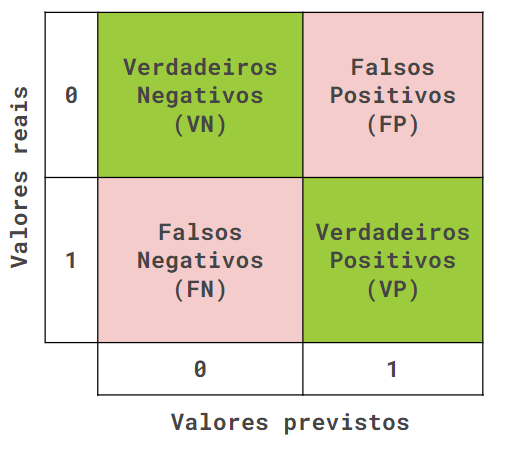

- Verdadeiros Negativos (VN): Quando o valor real for 0 e a predição também for 0. Indica que o modelo classificou corretamente os valores da classe negativa.
- Falsos Positivos (FP): Quando o valor real for 0 e a predição for 1. Indica que o modelo classificou erroneamente um elemento da classe negativa como se fosse da classe positiva.
- Falsos Negativos (FN): Quando o valor real for 1 e a predição for 0. Indica que o modelo classificou erroneamente um elemento da classe positiva como se fosse da classe negativa.
- Verdadeiros Positivos (VP): Quando o valor real for 1 e a predição também for 1. Indica que o modelo classificou corretamente os valores da classe positiva.